# Silver Databridge — Default Prediction (Random Forest)
**Target:** `default_12m` (binary: 0 = no default, 1 = default)

Pipeline:
1. Load & inspect data
2. Drop leakage / ID-like columns
3. Encode categoricals
4. Train/test split with stratification
5. Train Random Forest with class-weight balancing
6. Evaluate (classification report, ROC-AUC, confusion matrix)
7. Feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load & Inspect

In [ ]:
df = pd.read_csv('../data/bronze/bronze_databridge.csv')
print(f'Shape: {df.shape}')
df.head(3)

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

=== Data Types ===
source_system                 str
ocr_engine                    str
doc_type                      str
document_image_quality    float64
ocr_confidence            float64
ocr_error_count             int64
text_language                 str
normalized_amount         float64
normalized_date               str
normalization_method          str
match_score               float64
join_status                   str
uf                            str
regiao                        str
data_quality_score        float64
rule_violations             int64
pii_detected                int64
compliance_status             str
bioma                         str
precip_mm_30d             float64
drought_spi               float64
flood_risk_idx            float64
ndvi                      float64
fire_hotspots_30d           int64
deforestation_km2_12m     float64
climate_alert_level           str
customer_segment              str
industry_sector               str
credit_requested_value    flo

=== Target Distribution ===
             count   pct
default_12m             
0            20822  83.4
1             4152  16.6


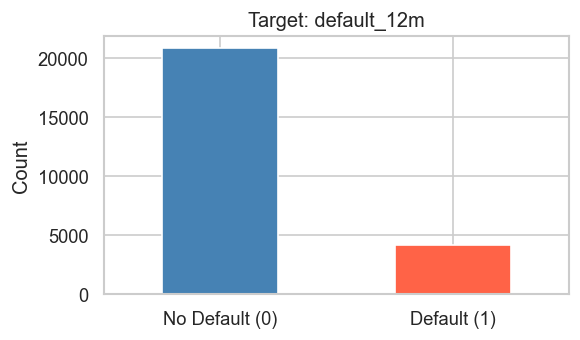

In [4]:
print('=== Target Distribution ===')
counts = df['default_12m'].value_counts()
pct = df['default_12m'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, 'pct': pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Target: default_12m')
ax.set_xlabel('')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Drop Leakage Columns

In [5]:
TARGET = 'default_12m'

# Columns to drop:
# - 'normalized_date'   : free-text date, not useful without parsing
# - 'is_duplicate'      : data-pipeline flag, not a real feature
# - 'final_decision'    : likely decided AFTER default is known (leakage)
# - 'requires_human_review' : post-hoc pipeline flag
DROP_COLS = ['normalized_date', 'is_duplicate', 'final_decision', 'requires_human_review']

df_model = df.drop(columns=DROP_COLS)
print(f'Columns after dropping: {df_model.shape[1]} (was {df.shape[1]})')

Columns after dropping: 35 (was 39)


## 3. Encode Categorical Features

In [6]:
cat_cols = df_model.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

df_encoded = df_model.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print('\nAll columns are now numeric:', df_encoded.dtypes.unique())

Categorical columns (15): ['source_system', 'ocr_engine', 'doc_type', 'text_language', 'normalization_method', 'join_status', 'uf', 'regiao', 'compliance_status', 'bioma', 'climate_alert_level', 'customer_segment', 'industry_sector', 'collateral_type', 'env_risk_level']

All columns are now numeric: [dtype('int64') dtype('float64')]


In [7]:
# Numeric summary of key financial features
num_cols = ['credit_requested_value', 'income_declared', 'ltv', 'pd_model_score',
            'tenure_months', 'data_quality_score']
df_encoded[num_cols].describe().round(2)

,credit_requested_value,income_declared,ltv,pd_model_score,tenure_months,data_quality_score
count,24974.00,24974.00,24974.00,24974.00,24974.00,24974.00
mean,17704.03,37929.47,0.57,0.32,119.55,0.72
std,12051.04,30652.43,0.50,0.11,69.18,0.07
min,1134.18,1954.45,0.01,0.09,1.00,0.43
25%,9734.80,18380.27,0.22,0.24,59.00,0.67
50%,14668.82,29523.31,0.40,0.30,120.00,0.72
75%,22161.94,47526.11,0.76,0.38,179.00,0.77
max,187961.00,446273.49,2.00,0.98,239.00,0.94


## 4. Train / Test Split

In [8]:
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserve class imbalance ratio
)

print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test size  : {X_test.shape[0]:,} rows')
print(f'\nTrain default rate : {y_train.mean():.2%}')
print(f'Test default rate  : {y_test.mean():.2%}')

Train size : 19,979 rows
Test size  : 4,995 rows

Train default rate : 16.63%
Test default rate  : 16.62%


## 5. Train Random Forest

We use `class_weight='balanced'` to handle the ~83/17 class imbalance.

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,          # trees grow fully unless min_samples_leaf stops them
    min_samples_leaf=5,      # light regularisation
    max_features='sqrt',     # standard for classification
    class_weight='balanced', # compensate for class imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 6. Evaluate on Test Set

In [10]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

  No Default       0.83      1.00      0.91      4165
     Default       0.00      0.00      0.00       830

    accuracy                           0.83      4995
   macro avg       0.42      0.50      0.45      4995
weighted avg       0.70      0.83      0.76      4995

ROC-AUC : 0.5784


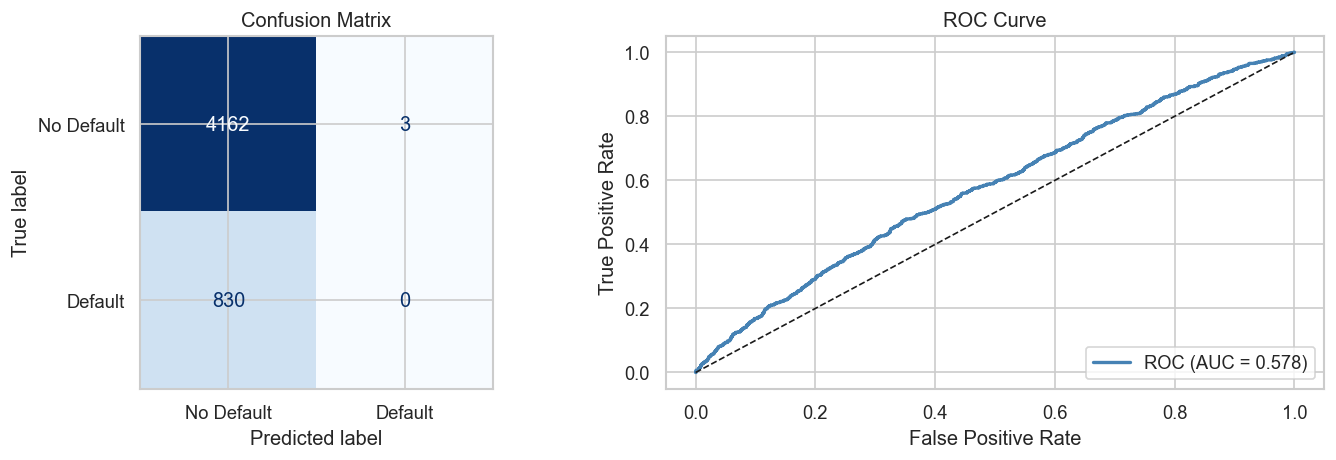

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- Confusion Matrix --
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# -- ROC Curve --
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7. Cross-Validated AUC (Sanity Check)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold CV ROC-AUC:')
for i, s in enumerate(cv_aucs, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}')

5-Fold CV ROC-AUC:
  Fold 1: 0.5838
  Fold 2: 0.5645
  Fold 3: 0.5456
  Fold 4: 0.5473
  Fold 5: 0.5633
  Mean : 0.5609 ± 0.0139


## 8. Feature Importance

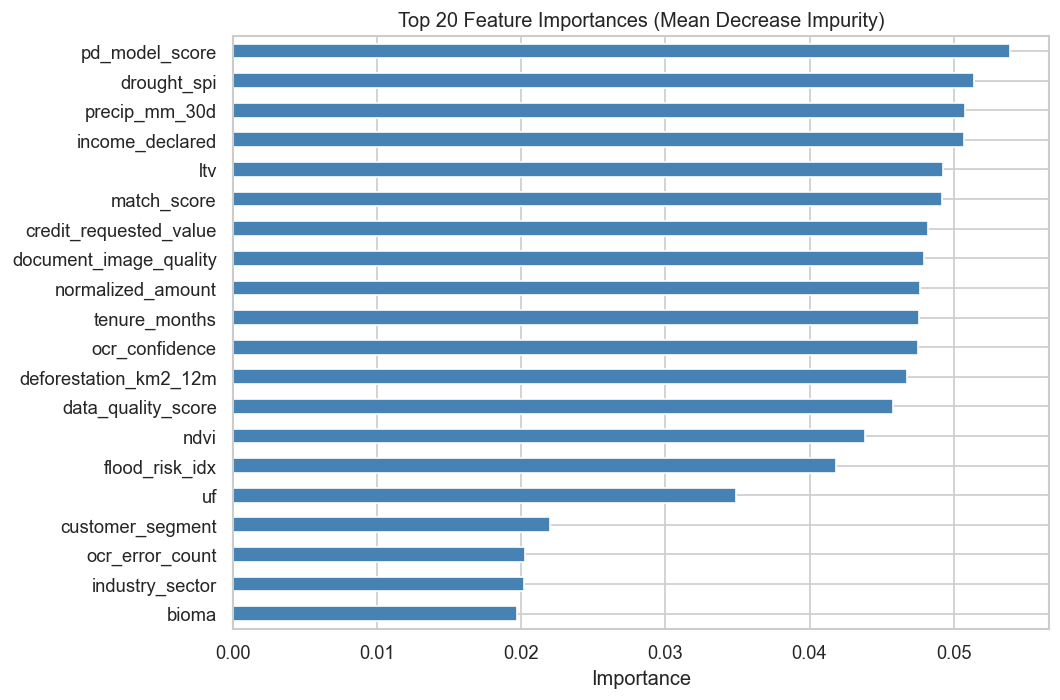


Top 10 features:
pd_model_score            0.0539
drought_spi               0.0514
precip_mm_30d             0.0508
income_declared           0.0507
ltv                       0.0492
match_score               0.0492
credit_requested_value    0.0482
document_image_quality    0.0479
normalized_amount         0.0477
tenure_months             0.0476


In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Mean Decrease Impurity)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(top20.head(10).round(4).to_string())

## Summary

| Item | Value |
|---|---|
| Dataset rows | 24 974 |
| Features used | 34 |
| Default rate | ~16.6% |
| Model | Random Forest (300 trees, balanced weights) |
| Test ROC-AUC | see above |
| CV ROC-AUC (5-fold) | see above |

**Next steps:**
- Try threshold tuning (e.g. `precision_recall_curve`) to optimise for business cost of FP vs FN.
- Experiment with SMOTE or other over-sampling for the minority class.
- Tune `n_estimators`, `max_depth`, `min_samples_leaf` with `RandomizedSearchCV`.
- Consider gradient boosted trees (XGBoost / LightGBM) for higher AUC.